# Notebook 05 — Mapa interactivo final (entregable principal)

Combinamos todo en un único `folium.Map`:
- **Base**: tiles OpenStreetMap
- **Overlay raster**: NDVI como `ImageOverlay` georreferenciado
- **Marcadores**: POIs turísticos con popups y tooltips
- **HeatMap**: plugin `folium.plugins.HeatMap` sobre los POIs
- **Líneas**: rutas desde OSM (`PolyLine`)
- **Polígono**: región Bogotá D.C. (`GeoJson`)
- **Plugins**: MiniMap, MousePosition, Fullscreen, LayerControl

**Salida**: `media/05_mapa_interactivo.html`

In [1]:
from pathlib import Path
import os
import json
import base64
import io
import numpy as np
import rasterio
import geopandas as gpd
import folium
from folium.plugins import MiniMap, MousePosition, Fullscreen, HeatMap, MarkerCluster
import matplotlib.pyplot as plt
from PIL import Image

def find_taller_root(start: Path, marker: str = "python/data/bogota_sabana_sentinel2.tif") -> Path:
    p = start.resolve()
    for parent in [p, *p.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"No se encontró {marker} desde {start}")

ROOT = find_taller_root(Path.cwd())
os.chdir(ROOT)
DATA = ROOT / "python" / "data"
MEDIA = ROOT / "media"
MEDIA.mkdir(exist_ok=True)
print("ROOT:", ROOT)

ROOT: /home/bellic12/Desktop/Visual/Semana_13_SLAM_Robotica_Visual/semana_13_2_mapas_interactivos_datos_satelitales


In [2]:
region = gpd.read_file(DATA / "region.geojson")
pois = gpd.read_file(DATA / "puntos_interes.geojson")
rutas = gpd.read_file(DATA / "rutas.geojson")
stats = json.load(open(DATA / "ndvi_stats.json"))
print("region:", len(region))
print("pois:", len(pois))
print("rutas:", len(rutas))
print("NDVI stats:", {k: stats[k] for k in ("ndvi_min", "ndvi_max", "ndvi_mean")})

region: 1
pois: 5
rutas: 30
NDVI stats: {'ndvi_min': -0.07971864193677902, 'ndvi_max': 0.676969587802887, 'ndvi_mean': 0.316254585981369}


In [3]:
tif = DATA / "bogota_sabana_sentinel2.tif"
with rasterio.open(tif) as src:
    b04 = src.read(3).astype(np.float32)
    b08 = src.read(4).astype(np.float32)
    bounds = src.bounds

np.seterr(divide="ignore", invalid="ignore")
ndvi = (b08 - b04) / (b08 + b04)
ndvi_clip = np.clip(ndvi, -0.2, 0.9)
ndvi_norm = (ndvi_clip + 0.2) / 1.1
rgba = plt.cm.RdYlGn(ndvi_norm)
alpha = np.where(np.isfinite(ndvi), 0.85, 0.0)
rgba[..., 3] = alpha

buf = io.BytesIO()
Image.fromarray((rgba * 255).astype(np.uint8), mode="RGBA").save(buf, format="PNG")
ndvi_b64 = base64.b64encode(buf.getvalue()).decode()
print(f"NDVI PNG embebido: {len(ndvi_b64)/1024:.1f} KB (base64)")

NDVI PNG embebido: 190.9 KB (base64)



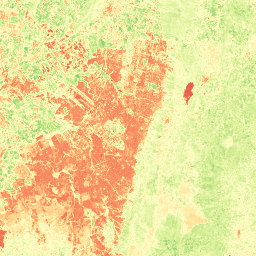

In [4]:
CENTER = [4.66, -74.07]
ZOOM = 10

m = folium.Map(
    location=CENTER,
    zoom_start=ZOOM,
    tiles=None,
    control_scale=True,
)

folium.TileLayer("OpenStreetMap", name="OpenStreetMap").add_to(m)
folium.TileLayer("CartoDB positron", name="CartoDB Positron").add_to(m)
folium.TileLayer("CartoDB dark_matter", name="CartoDB Dark").add_to(m)

image_overlay = folium.raster_layers.ImageOverlay(
    image=f"data:image/png;base64,{ndvi_b64}",
    bounds=[[bounds.bottom, bounds.left], [bounds.top, bounds.right]],
    opacity=0.65,
    name="NDVI Sentinel-2",
    interactive=True,
    cross_origin=False,
)
image_overlay.add_to(m)

region_layer = folium.GeoJson(
    region,
    name="Región Bogotá D.C.",
    style_function=lambda f: {
        "color": "black",
        "weight": 2,
        "fillColor": "#3388ff",
        "fillOpacity": 0.02,
        "dashArray": "6,4",
    },
    tooltip=folium.GeoJsonTooltip(fields=["display_name"], aliases=["Región:"]),
).add_to(m)

color_by_type = {
    "primary": "#e74c3c",
    "secondary": "#f39c12",
    "trunk": "#c0392b",
    "motorway": "#8e44ad",
}
def _style_edge(feat):
    hw = str(feat["properties"].get("highway", "")).lower()
    color = "#888"
    for k, v in color_by_type.items():
        if k in hw:
            color = v
            break
    return {"color": color, "weight": 3, "opacity": 0.85}

rutas_layer = folium.GeoJson(
    rutas,
    name="Vías (OSM)",
    style_function=_style_edge,
    tooltip=folium.GeoJsonTooltip(
        fields=[c for c in ["name", "highway"] if c in rutas.columns],
        aliases=[a for a in ["Nombre:", "Tipo:"] if (a, True) or True][: 2 if "name" in rutas.columns and "highway" in rutas.columns else (1 if "name" in rutas.columns or "highway" in rutas.columns else 0)],
    ),
).add_to(m)

poi_group = folium.FeatureGroup(name="POIs turísticos", show=True).add_to(m)
marker_cluster = MarkerCluster().add_to(poi_group)
icon_colors = {
    "museum": "darkblue",
    "attraction": "green",
    "hotel": "orange",
    "information": "blue",
    "viewpoint": "purple",
}
for _, row in pois.iterrows():
    name = row.get("name") or row.get("tourism", "POI")
    tourism = row.get("tourism", "")
    color = icon_colors.get(tourism, "red")
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        popup=folium.Popup(f"<b>{name}</b><br>Tipo: {tourism}<br>Lon: {row.geometry.x:.4f}<br>Lat: {row.geometry.y:.4f}", max_width=300),
        tooltip=f"{name} ({tourism})",
        icon=folium.Icon(color=color, icon="info-sign"),
    ).add_to(marker_cluster)

heat_points = [[row.geometry.y, row.geometry.x] for _, row in pois.iterrows()]

# Embalse San Rafael (cuerpo de agua visible como NDVI bajo en la zona oriental)
folium.Marker(
    location=[4.71, -74.005],
    popup=folium.Popup("<b>Embalse San Rafael</b><br>Cuerpo de agua artificial<br>NDVI ≈ 0.05", max_width=300),
    tooltip="Embalse San Rafael",
    icon=folium.Icon(color="darkblue", icon="tint", prefix="fa"),
).add_to(m)
if heat_points:
    HeatMap(
        heat_points,
        name="HeatMap POIs",
        radius=35,
        blur=25,
        min_opacity=0.4,
        show=False,
    ).add_to(m)

MiniMap(tile_layer="OpenStreetMap", position="bottomright", width=180, height=180, zoom_level_offset=-5).add_to(m)
MousePosition(position="bottomleft", separator=" , ", prefix="lat,lon:", num_digits=4).add_to(m)
Fullscreen(position="topleft").add_to(m)
folium.LayerControl(collapsed=False, position="topright").add_to(m)

legend_html = """
<div style=\"position: fixed; bottom: 30px; left: 12px; z-index:9999; font-size:11px; background:white; padding:8px 10px; border:2px solid #444; border-radius:4px; box-shadow:0 1px 4px rgba(0,0,0,0.3);\">
  <b>NDVI</b><br>
  <span style=\"background:#d73027;color:white;padding:1px 6px\">&lt; 0</span>
  <span style=\"background:#fc8d59;color:white;padding:1px 6px\">0-0.2</span>
  <span style=\"background:#fee08b;color:black;padding:1px 6px\">0.2-0.4</span>
  <span style=\"background:#d9ef8b;color:black;padding:1px 6px\">0.4-0.6</span>
  <span style=\"background:#91cf60;color:black;padding:1px 6px\">0.6-0.8</span>
  <span style=\"background:#1a9850;color:white;padding:1px 6px\">&gt; 0.8</span><br>
  <small>Media: {mean:.3f} | Min: {mn:.3f} | Max: {mx:.3f}</small>
</div>
""".format(mean=stats["ndvi_mean"], mn=stats["ndvi_min"], mx=stats["ndvi_max"])
m.get_root().html.add_child(folium.Element(legend_html))

title_html = """
<div style=\"position: fixed; top: 12px; left: 60px; z-index:9999; font-size:13px; background:rgba(255,255,255,0.92); padding:6px 10px; border:2px solid #444; border-radius:4px; box-shadow:0 1px 4px rgba(0,0,0,0.3);\">
  <b>Mapas Interactivos — Sabana de Bogotá</b><br>
  <small>Sentinel-2 L2A (NDVI) + OpenStreetMap</small>
</div>
"""
m.get_root().html.add_child(folium.Element(title_html))

m

In [5]:
html_path = MEDIA / "05_mapa_interactivo.html"
m.save(str(html_path))
print(f"HTML guardado: {html_path} ({html_path.stat().st_size/1024:.1f} KB)")

HTML guardado: /home/bellic12/Desktop/Visual/Semana_13_SLAM_Robotica_Visual/semana_13_2_mapas_interactivos_datos_satelitales/media/05_mapa_interactivo.html (437.6 KB)


## Conclusiones

El mapa `folium` combina:
1. **3 tiles base** (OSM, CartoDB Positron, CartoDB Dark) seleccionables desde el `LayerControl`.
2. **NDVI georreferenciado** como `ImageOverlay` PNG embebido en base64 (no requiere archivos externos).
3. **Región Bogotá D.C.** como polígono.
4. **Vías (rutas)** coloreadas por tipo de vía con tooltips.
5. **POIs turísticos** con popups informativos y cluster de marcadores.
6. **HeatMap** opcional sobre POIs (desactivada por defecto).
7. **MiniMap, MousePosition, Fullscreen** como plugins de UX.
8. **Leyenda NDVI** y **título** como elementos HTML personalizados.

En el notebook 06 capturaremos una secuencia de pantallas con Playwright para producir el GIF demostrativo.